In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Apply same fixes as EDA
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(df.shape)
print("Data loaded successfully")

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(7043, 21)
Data loaded successfully


In [4]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [5]:
print(df.shape)
print(df['Churn'].value_counts())
print(df.isnull().sum().sum())  # should be 0


(7043, 31)
Churn
0    5174
1    1869
Name: count, dtype: int64
0


In [7]:
# Split features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE to training data only (never on test data)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Original train size: {X_train.shape}")
print(f"After SMOTE: {X_train_sm.shape}")
print(f"Churn balance after SMOTE:\n{pd.Series(y_train_sm).value_counts()}")

Original train size: (5634, 30)
After SMOTE: (8278, 30)
Churn balance after SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [8]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# 1. Logistic Regression (baseline)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_sm)
lr_preds = lr.predict(X_test_scaled)

# 2. XGBoost
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_sm, y_train_sm)
xgb_preds = xgb_model.predict(X_test)

# 3. LightGBM
lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
lgb_model.fit(X_train_sm, y_train_sm)
lgb_preds = lgb_model.predict(X_test)

print("All 3 models trained successfully")

All 3 models trained successfully


In [10]:
# Compare all 3 models
models = {
    'Logistic Regression': (lr_preds, y_test),
    'XGBoost': (xgb_preds, y_test),
    'LightGBM': (lgb_preds, y_test)
}

for name, (preds, actual) in models.items():
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"{'='*40}")
    print(classification_report(actual, preds, target_names=['No Churn', 'Churn']))
    print(f"ROC-AUC: {roc_auc_score(actual, preds):.4f}")


Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.86      0.79      0.82      1035
       Churn       0.52      0.64      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.75      0.76      1409

ROC-AUC: 0.7124

XGBoost
              precision    recall  f1-score   support

    No Churn       0.85      0.82      0.84      1035
       Churn       0.55      0.60      0.58       374

    accuracy                           0.77      1409
   macro avg       0.70      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409

ROC-AUC: 0.7129

LightGBM
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.55      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
we

In [12]:
# SHAP explanation on LightGBM
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# Check shape
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(1409, 30)


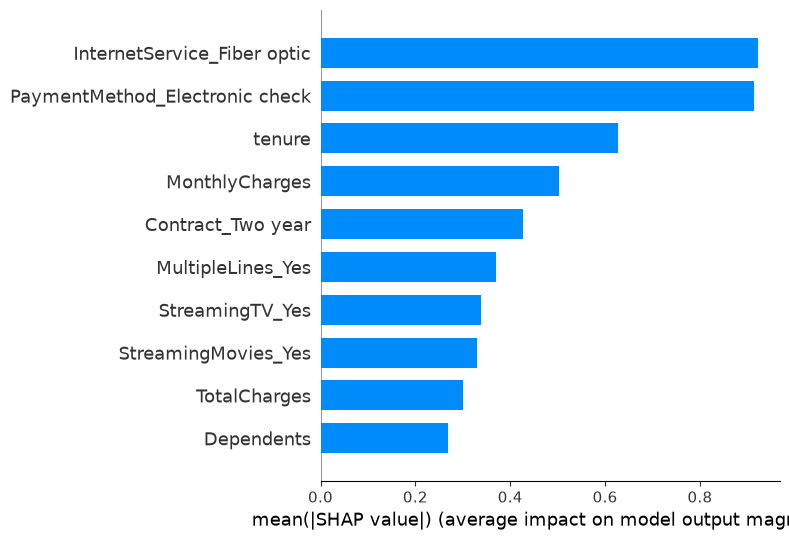

In [13]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=10,
    show=True
)

In [15]:
import joblib

# Save model, scaler and feature names
joblib.dump(lgb_model, '../app/model.pkl')
joblib.dump(scaler, '../app/scaler.pkl')
joblib.dump(list(X_test.columns), '../app/features.pkl')

print("Model, scaler and features saved successfully")

Model, scaler and features saved successfully
